In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

In [2]:
PROJECT_ROOT = (Path(__vsc_ipynb_file__).parents[1] / "scripts/train_pos_control")
# PROJECT
DISTANCE_CONTROL_2B = PROJECT_ROOT / "runs/2B_DistanceControl"
DISTANCE_CONTROL_3B = PROJECT_ROOT / "runs/3B_DistanceControl"
DISTANCE_CONTROL_4B = PROJECT_ROOT / "runs/4B_DistanceControl"

METRIC_DIR = PROJECT_ROOT / "metrics"

In [3]:
def list_tb_run_dirs(log_dir):
    return sorted({
        p.parent
        for p in Path(log_dir).rglob("events.out.tfevents.*")
    })

In [4]:
def list_metrics(metric_dir):
    return sorted(Path(metric_dir).iterdir())

In [15]:
def list_run_and_data(logs, metrics, matched_only=True):
    rows = []

    metrics_by_stem = {
        Path(metric).stem: Path(metric)
        for metric in metrics
    }

    for log in logs:
        log = Path(log)
        run_name = log.name

        metric_path = metrics_by_stem.get(run_name)
        if matched_only and metric_path is None:
            continue

        rows.append({
            "run": run_name,
            "tb_log": log,
            "stat_file": metric_path,
            "has_stat": metric_path is not None,
        })

    return pd.DataFrame(rows)

In [ ]:
def add_hparams(df, tag="hyperparameters/text_summary"):
    # Ebbe a listába gyűjtjük az egyes sorok kinyert hiperparamétereit
    extracted_hparams_list = []

    # Fontos: az iterrows() egy (index, row) párost ad vissza!
    for idx, row in df.iterrows():
        tb = str(row['tb_log'])
        hparams = {}  # Alapértelmezetten üres, ha nincs hparam a logban

        try:
            ea = EventAccumulator(tb)
            ea.Reload()

            # Ellenőrizzük, hogy a tag egyáltalán létezik-e a logfájlban
            if 'tensors' in ea.Tags() and tag in ea.Tags()['tensors']:
                events = ea.Tensors(tag)
                
                if events:
                    text = events[-1].tensor_proto.string_val[0].decode("utf-8")

                    for line in text.splitlines():
                        line = line.strip()

                        if not line.startswith("|"):
                            continue
                        # Kis betűs alakban ellenőrizzük, kiszűrve a whitespace-eket
                        clean_line = line.replace(" ", "").lower()
                        if clean_line in {"|param|value|", "|-|-|"}:
                            continue

                        parts = [p.strip() for p in line.strip("|").split("|")]
                        if len(parts) == 2:
                            key, value = parts
                            hparams[key] = value
        except Exception as e:
            print(f"Hiba a következő log feldolgozásakor: {tb}. Hiba: {e}")
            
        # Mindenképp hozzáadjuk a listához (akár üres, akár találtunk paramétereket)
        # Így a lista hossza pontosan meg fog egyezni a DataFrame soraival
        extracted_hparams_list.append(hparams)

    # 1. Létrehozunk egy új DataFrame-et a kinyert szótárak listájából
    hparams_df = pd.DataFrame(extracted_hparams_list, index=df.index)

    # 2. Összefűzzük az eredeti DataFrame-et az új oszlopokkal az index mentén
    # Az eredeti df érintetlen marad, a függvény egy kiterjesztett másolatot ad vissza
    return pd.concat([df, hparams_df], axis=1)
    

In [26]:
def add_stats(df):
    extracted_stats_list = []

    for idx, row in df.iterrows():
        csv_path = str(row['stat_file'])
        stats = {
            'success_rate': np.nan,
            'timeout_rate': np.nan,
            'failure_rate': np.nan,
            'success_ep_len_mean': np.nan,
            'success_ep_len_std': np.nan,
            'success_ep_return_mean': np.nan,
            'success_ep_return_std': np.nan
        }

        try:
            # 1. Beolvassuk a futási CSV-t
            data = pd.read_csv(csv_path)
            total_episodes = len(data)
            
            if total_episodes == 0:
                extracted_stats_list.append(stats)
                continue

            # 2. Definiáljuk a feltételeket a teljes oszlopokra (Vektoros művelet)
            conditions = [
                (data['episode_returns'] > 0) & (data['episode_lengths'] < 128),              # Success
                (data['episode_lengths'] == 128) & (data['episode_returns'] > -100)          # Timeout
            ]
            choices = ['success', 'timeout']
            
            # Ha egyik feltétel sem teljesül, az alapértelmezett (default) a 'failure'
            data['status'] = np.select(conditions, choices, default='failure')

            # 3. Arányok kiszámítása (hányszor fordult elő az adott állapot)
            status_counts = data['status'].value_counts()
            stats['success_rate'] = status_counts.get('success', 0) / total_episodes
            stats['timeout_rate'] = status_counts.get('timeout', 0) / total_episodes
            stats['failure_rate'] = status_counts.get('failure', 0) / total_episodes

            # 4. Szűrés KIZÁRÓLAG a sikeres epizódokra
            success_data = data[data['status'] == 'success']

            # 5. Statisztikák számítása (csak ha volt legalább egy sikeres epizód)
            if not success_data.empty:
                stats['success_ep_len_mean'] = success_data['episode_lengths'].mean()
                # ddof=1 az empirikus szóráshoz (Sample STD), ha csak 1 elem van, NaN-t ad, ami korrekt
                stats['success_ep_len_std'] = success_data['episode_lengths'].std(ddof=1) 
                
                stats['success_ep_return_mean'] = success_data['episode_returns'].mean()
                stats['success_ep_return_std'] = success_data['episode_returns'].std(ddof=1)

        except Exception as e:
            print(f"Hiba a fájl feldolgozásakor: {csv_path}. Hiba: {e}")

        extracted_stats_list.append(stats)

    # Összefűzzük az új statisztikai oszlopokat a fő DataFrame-mel
    stats_df = pd.DataFrame(extracted_stats_list, index=df.index)
    return pd.concat([df, stats_df], axis=1)


## 2 Bubbles

In [17]:
metrics_2B = list_metrics(METRIC_DIR)
runs_2B = list_tb_run_dirs(DISTANCE_CONTROL_2B)
df2b_map = list_run_and_data(runs_2B, metrics_2B)

In [ ]:
df2b_map = add_hparams(df2b_map)
df2b_map

In [27]:
df2b_map = add_stats(df2b_map)

In [45]:
df2b_map['num_envs'] = df2b_map['num_envs'].astype(int)
df2b_map['rollout_steps'] = df2b_map['rollout_steps'].astype(int)

In [42]:
def plot_eval_summary(stats_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

    plots = [
        ("success_rate", None, "Success rate"),
        ("success_ep_return_mean", "success_ep_return_std", "Success episode return"),
        ("success_ep_len_mean", "success_ep_len_std", "Success episode length"),
    ]

    for ax, (y, yerr, title) in zip(axes, plots):
        for rollout_steps, g in stats_df.groupby("rollout_steps"):
            g = g.sort_values("num_envs")

            if yerr is None:
                ax.plot(
                    g["num_envs"],
                    g[y],
                    marker="o",
                    label=f"rollout={rollout_steps}",
                )
            else:
                ax.errorbar(
                    g["num_envs"],
                    g[y],
                    yerr=g[yerr],
                    marker="o",
                    capsize=3,
                    label=f"rollout={rollout_steps}",
                )

        ax.set_xscale("log", base=2)
        ax.set_xlim(512, 8192)
        ax.set_xlabel("num_envs")
        ax.set_title(title)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("rate")
    axes[1].set_ylabel("return")
    axes[2].set_ylabel("steps")

    axes[-1].legend(title="rollout steps", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()

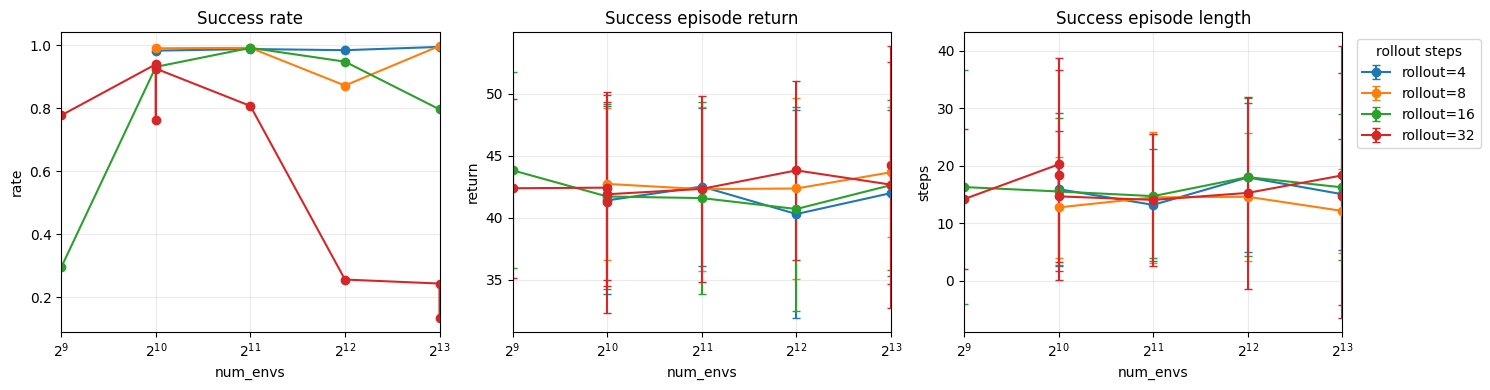

In [48]:
plot_eval_summary(df2b_map)

In [52]:
df2b_map[df2b_map['num_envs'] == 1024][['rollout_steps', 'success_rate']]

,rollout_steps,success_rate
0,32,0.940028
1,32,0.761443
2,32,0.926159
3,16,0.931671
4,8,0.990623
5,4,0.983177


In [ ]:


def read_tb_log(log):
    event_acc = EventAccumulator(str(log))
    event_acc.Reload()
    hpars = _read_hyperparameters(event_acc)

    rows = []
    for tag in event_acc.Tags().get("scalars", []):
        for event in event_acc.Scalars(tag):
            rows.append({
                "tag": tag,
                "step": event.step,
                "wall_time": event.wall_time,
                "value": event.value,
            })

    return pd.DataFrame(rows), hpars

In [32]:
def tensorboard_smooth(values, smoothing=0.95):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values

    smoothed = []
    last = values[0]
    for v in values:
        last = last * smoothing + (1 - smoothing) * v
        smoothed.append(last)
    return np.array(smoothed)


def plot_tb_style(df, tag, smoothing=0.95, show_raw=True):
    data = (
        df[df["tag"] == tag]
        .copy()
        .sort_values("step")
    )

    data["smoothed"] = tensorboard_smooth(data["value"].values, smoothing=smoothing)

    plt.figure(figsize=(10, 5))

    if show_raw:
        plt.plot(data["step"], data["value"], alpha=0.15, label="raw")

    plt.plot(data["step"], data["smoothed"], linewidth=2, label="smoothed")
    plt.title(f"{tag} by training step")
    plt.xlabel("step")
    plt.ylabel("value")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [68]:
df, hpars = read_tb_log(LOGS_2B[0])

In [69]:
df

,tag,step,wall_time,value
0,charts/episode_return,17,1.777322e+09,49.937782
1,charts/episode_return,57,1.777322e+09,49.943115
2,charts/episode_return,67,1.777322e+09,49.264343
3,charts/episode_return,73,1.777322e+09,49.164417
4,charts/episode_return,82,1.777322e+09,47.727997
...,...,...,...,...
30987,perf/DPS,29884416,1.777382e+09,499.972473
30988,perf/DPS,29917184,1.777382e+09,500.121338
30989,perf/DPS,29949952,1.777382e+09,500.275208
30990,perf/DPS,29982720,1.777382e+09,500.433807


In [70]:
hpars

{'gamma': '0.99',
 'gae_lambda': '0.95',
 'mini_batch_size': '512',
 'clip_coef': '0.2',
 'clip_vloss': 'True',
 'ent_coef': '0.01',
 'vf_coef': '0.5',
 'max_grad_norm': '2.5',
 'target_kl': 'None',
 'norm_adv': 'False',
 'num_envs': '1024',
 'rollout_steps': '32',
 'num_update_epochs': '16',
 'gradient_steps': '1024',
 'seed': '42',
 'buffer_device': 'cuda',
 'policy_type': 'Beta',
 'hidden_dims': '[256, 256]',
 'activations': "['tanh', 'tanh']",
 'shared_dims': '0'}

In [72]:
def plot_episode_return_by_episode(df, smoothing=0.95):
    data = (
        df[df["tag"] == "charts/episode_length"]
        .copy()
        .sort_values("step")
        .reset_index(drop=True)
    )

    data["episode"] = data.index + 1
    data["smoothed"] = tensorboard_smooth(data["value"].values, smoothing=smoothing)

    plt.figure(figsize=(10, 5))
    plt.plot(data["episode"], data["value"], alpha=0.15, label="raw")
    plt.plot(data["episode"], data["smoothed"], linewidth=2, label="smoothed")
    plt.ylim(data["smoothed"].min() - 10, data["smoothed"].max() + 10)
    plt.grid(alpha=0.2)
    plt.xlabel("episode")
    plt.ylabel("lenght")
    plt.title("Episode return by episode")
    plt.legend()
    plt.tight_layout()
    plt.show()

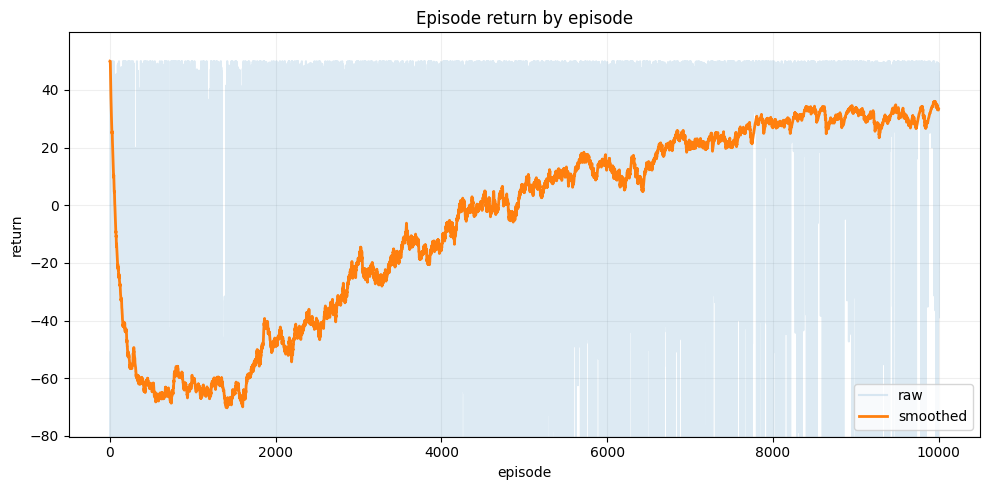

In [71]:
plot_episode_return_by_episode(df, 0.99)

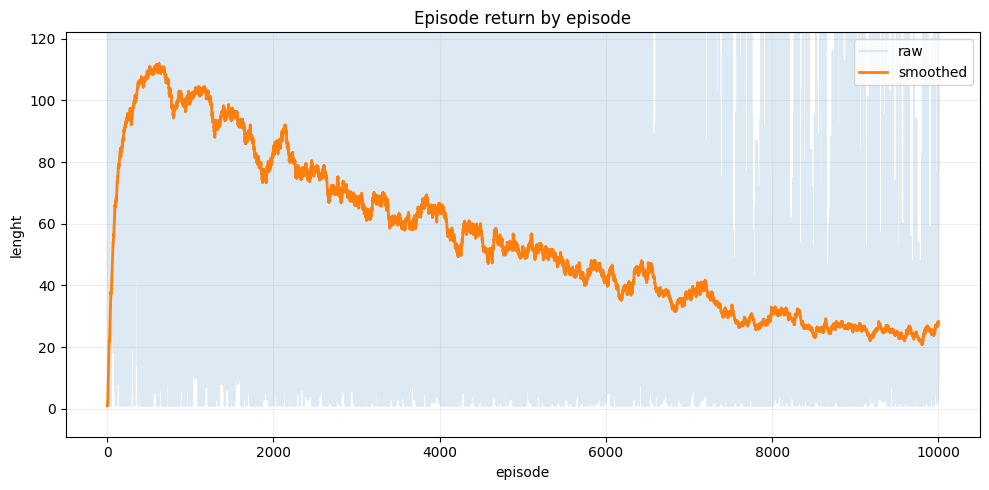

In [73]:
plot_episode_return_by_episode(df, 0.99)